$$
\begin{array}{c}
{\Huge \text{CAUSAL INFERENCE LAB 4}}\\
{\Large \textbf{Abhishek Bakshi}} \\
{\large \textit{Center for Data Science, New York University}} \\\\
{\Large \text{Office Hours: Wednesdays, 12:30 - 1:30 pm}} \\
{\Large \textit{Room 242, 60 5th Ave, 2nd floor}} \\\\
\text{Materials prepared by: Abhishek Bakshi, Xiang Gao}
\end{array}
$$

---

<p align="center">
    <img src="../images/images.jpeg" alt="Hypothesis Testing" width="760">
</p>

<h1 style="font-size: 42px;">Experiments</h1>

---

<h1 style="font-size: 30px;">Today's Goals:</h1>

<ol style="font-size: 20px; line-height: 1.6;">
  <li>More hypothesis testing</li>
  <li>Confidence intervals</li>
  <li>Identification assumptions for ATE</li>
  <li>Estimation</li>
  <li>ATE vs ITT</li>
</ol>

---

<style>
body,
.jp-RenderedHTMLCommon,
.jp-RenderedMarkdown,
.markdown-body,
.vscode-body {
  font-family: Arial, Helvetica, sans-serif !important;
}

p, li, blockquote, td, th {
  font-size: 20px !important;
  line-height: 1.6 !important;
}

h1 {
  font-family: Arial, Helvetica, sans-serif !important;
  font-size: 42px !important;
  line-height: 1.25 !important;
  margin-top: 0.6em !important;
}

h2 {
  font-family: Arial, Helvetica, sans-serif !important;
  font-size: 30px !important;
  line-height: 1.3 !important;
  margin-top: 0.7em !important;
  border-bottom: 2px solid #4b4bb7;
  padding-bottom: 0.15em;
}

h3 {
  font-family: Arial, Helvetica, sans-serif !important;
  font-size: 25px !important;
  line-height: 1.35 !important;
  margin-top: 0.7em !important;
}

table { font-size: 19px !important; line-height: 1.45 !important; }
code, pre { font-size: 17px !important; }
blockquote { border-left: 5px solid #4b4bb7 !important; padding: 0.3em 0.8em !important; }
.MathJax, mjx-container { font-size: 115% !important; }
</style>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

pd.set_option("display.precision", 3)
plt.rcParams.update({
    "font.size": 15, "axes.titlesize": 19, "axes.labelsize": 16,
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.constrained_layout.use": True,
})

rng = np.random.default_rng(2026)

def report(result, sided="two-sided", alpha=0.05):
    critical = stats.t.ppf(1 - alpha / 2 if sided == "two-sided" else 1 - alpha, result.df)
    reject_critical = abs(result.statistic) > critical if sided == "two-sided" else result.statistic > critical
    print(f"t = {result.statistic:.3f}; df = {result.df:.1f}; p = {result.pvalue:.4g}")
    print(f"critical value = {critical:.3f}")
    print("p-value decision:", "reject H0" if result.pvalue < alpha else "fail to reject H0")
    print("critical-value decision:", "reject H0" if reject_critical else "fail to reject H0")

print("Ready: confidence intervals and experiments.")

Ready: confidence intervals and experiments.


## 1. Hypothesis testing

A key goal in causal inference is to make informed decisions based on sample data. Hypothesis testing helps us decide whether to **reject** or **fail to reject** a claim about a population parameter based on evidence from our data.

### Framework

1. **Null Hypothesis ($H_0$)**:  
   Represents the default assumption we aim to **disprove**. For example, in a medical trial, it might state that a new treatment has no effect.

2. **Alternative Hypothesis ($H_1$)**:  
   What we want to really **test** through analysis, proposing an outcome different from $H_0$. For instance, it may claim that the new treatment **does** have an effect.

3. **Test Statistic ($T_n$)**:  
   A measure of how far our sample data deviates from expectations under $H_0$, quantifying the strength of evidence against it.

4. **Critical Value ($c$)**:  
   A threshold defining what is “significant” evidence. If our test statistic exceeds this value, we reject $H_0$.

5. **Decision Rule**:  
   If the test statistic is greater than the critical value $c$ or the p-value is less than the significance level, we reject $H_0$ in favor of $H_1$. If it's lower than the critical value or the p-value is greater than the significance level, we **fail to reject** $H_0$. Note that failing to reject $H_0$ does not prove it true; it just indicates insufficient evidence against it.

> **Significance** ($\alpha$) and **p-value**: A result is considered **significant** if the evidence against $H_0$ is strong. The **p-value** measures this evidence. It indicates the probability of observing data at least as extreme as ours if $H_0$ were true. A low p-value (typically < 0.05) suggests strong evidence against $H_0$.


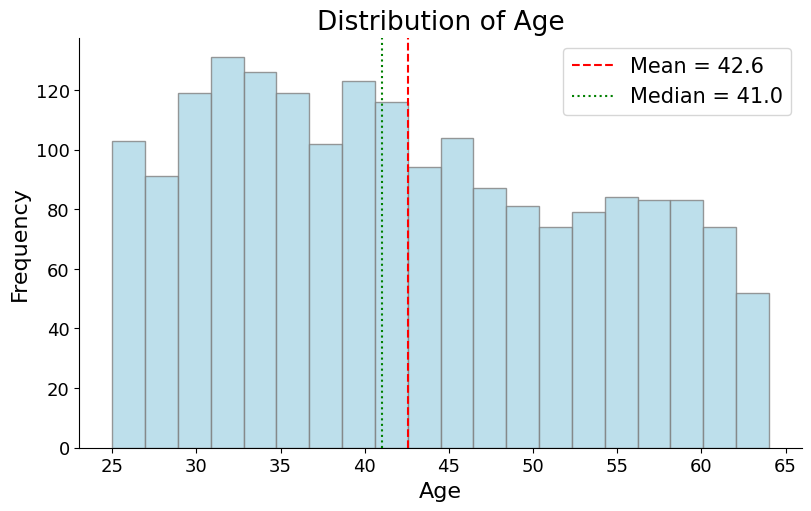

In [2]:
gss = pd.read_csv(Path("../data/gss_2022_education_income.csv"))
age = gss["age"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(age, bins=20, color="lightblue", edgecolor="gray", alpha=0.8)
plt.axvline(np.mean(age), color="red", linestyle="--", label=f"Mean = {np.mean(age):.1f}")
plt.axvline(np.median(age), color="green", linestyle=":", label=f"Median = {np.median(age):.1f}")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.legend()
plt.show()


### Example 1

We want to test whether the average age of the GSS population is 41 or not. How do we test this according to the Hypothesis testing framework?

$$H_0:\mu_{age}=41,\qquad H_1:\mu_{age}\ne41.$$

In [3]:
## Manual hypothesis test
alpha = 0.05
critical_values_t = stats.t.ppf(alpha / 2, df=len(age) - 1), stats.t.ppf(1 - alpha / 2, df=len(age) - 1)
critical_values_z = stats.norm.ppf(alpha / 2), stats.norm.ppf(1 - alpha / 2)
statistic = (np.mean(age) - 41) / (np.std(age, ddof=1) / np.sqrt(len(age)))
p_value = 2 * (1 - stats.t.cdf(abs(statistic), df=len(age) - 1))
print(f"Critical t-values: {critical_values_t[0]:.3f}, {critical_values_t[1]:.3f}, Critical z-values: {critical_values_z[0]:.3f}, {critical_values_z[1]:.3f}")
print(f"t = {statistic:.3f}; df = {len(age) - 1:.1f}; p = {p_value:.4g}")

## Hypothesis test using scipy
two = stats.ttest_1samp(age, popmean=41, alternative="two-sided")
print(f"t = {two.statistic:.3f}; df = {two.df:.1f}; p = {two.pvalue:.4g}")

Critical t-values: -1.961, 1.961, Critical z-values: -1.960, 1.960
t = 6.254; df = 1924.0; p = 4.931e-10
t = 6.254; df = 1924.0; p = 4.931e-10


### Example 2

Do female and male respondents have equal years of education on average?

$$H_0:\mu_{female}=\mu_{male},\qquad H_1:\mu_{female}\ne\mu_{male}.$$

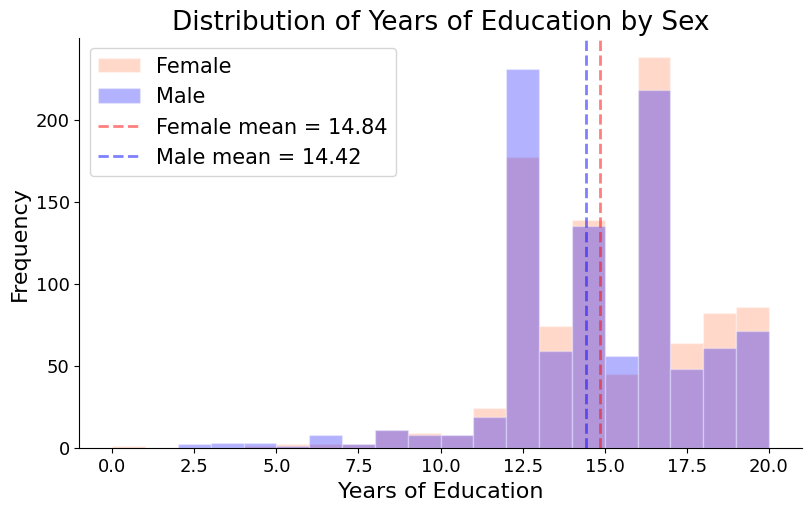

In [4]:
female = gss.loc[gss.sex == "female", "years_education"].dropna()
male = gss.loc[gss.sex == "male", "years_education"].dropna()

bins = np.arange(min(female.min(), male.min()), max(female.max(), male.max()) + 1)

female_mean = female.mean()
male_mean = male.mean()

plt.figure(figsize=(8, 5))
plt.hist(female, bins=bins, alpha=0.3, color="coral", label="Female", edgecolor="white")
plt.hist(male, bins=bins, alpha=0.3, color="blue", label="Male", edgecolor="white")

# Average education
plt.axvline(female_mean, color="red", alpha=0.5, linestyle="--", linewidth=2, label=f"Female mean = {female_mean:.2f}")
plt.axvline(male_mean, color="blue", alpha=0.5, linestyle="--", linewidth=2, label=f"Male mean = {male_mean:.2f}")

plt.xlabel("Years of Education")
plt.ylabel("Frequency")
plt.title("Distribution of Years of Education by Sex")

plt.legend()
plt.show()

In [5]:
two = stats.ttest_ind(female, male, equal_var=False, alternative="two-sided")
print(f"female mean = {female.mean():.2f}; male mean = {male.mean():.2f}")
print(f"t = {two.statistic:.3f}; df = {two.df:.1f}; p = {two.pvalue:.4g}")

female mean = 14.84; male mean = 14.42
t = 3.253; df = 1897.1; p = 0.001161


### Example 3

Is the annual family income higher for respondents with a bachelor's degree?

$$H_0:\mu_{degree}=\mu_{no\ degree},\qquad H_1:\mu_{degree}>\mu_{no\ degree}.$$

In [6]:
income_degree = gss.loc[gss.bachelors_or_more == 1, "annual_family_income"].dropna()
income_no_degree = gss.loc[gss.bachelors_or_more == 0, "annual_family_income"].dropna()

print(gss.groupby("bachelors_or_more")["annual_family_income"].mean())

bachelors_or_more
0.0    45724.899
1.0    83216.337
Name: annual_family_income, dtype: float64


In [7]:
greater = stats.ttest_ind(income_degree, income_no_degree, equal_var=False, alternative="greater")
print(f"degree mean = {income_degree.mean():,.0f}; no-degree mean = {income_no_degree.mean():,.0f}")
print(f"t = {greater.statistic:.3f}; df = {greater.df:.1f}; p = {greater.pvalue:.4g}")

degree mean = 83,216; no-degree mean = 45,725
t = 17.679; df = 1412.1; p = 1.212e-63


## 2. Confidence intervals
For a given distribution $F$ of the test statistic $\hat{\theta}$, a confidence interval at significance level $\alpha$ is given by,

$$\hat{\theta} \pm F^{-1}\left(1-\frac{\alpha}{2}\right) * SE(\hat{\theta})$$

The parameter is fixed and the interval is random. A 95% CI covers the population parameter in about 95% of repeated samples.

### Confidence intervals for the three examples

In [8]:
# Example 1: one-sample CI for the population mean age.
age_se = age.std(ddof=1) / np.sqrt(len(age))
age_ci = stats.t.interval(0.95, len(age) - 1, loc=age.mean(), scale=age_se)

# Example 2: CI for the female-minus-male mean education difference.
education_diff = female.mean() - male.mean()
education_se = np.sqrt(female.var(ddof=1) / len(female) + male.var(ddof=1) / len(male))
education_ci = (
    education_diff - stats.t.ppf(0.975, two.df) * education_se,
    education_diff + stats.t.ppf(0.975, two.df) * education_se,
)

# Example 3: CI for the degree-minus-no-degree mean income difference.
income_diff = income_degree.mean() - income_no_degree.mean()
income_se = np.sqrt(
    income_degree.var(ddof=1) / len(income_degree)
    + income_no_degree.var(ddof=1) / len(income_no_degree)
)
income_ci = (
    income_diff - stats.t.ppf(0.975, greater.df) * income_se,
    income_diff + stats.t.ppf(0.975, greater.df) * income_se,
)

ci_summary = pd.DataFrame({
    "Example": [
        "1. Mean age",
        "2. Female minus male mean education",
        "3. Degree minus no-degree mean income",
    ],
    "Estimate": [age.mean(), education_diff, income_diff],
    "95% two-sided CI": [
        f"({age_ci[0]:.2f}, {age_ci[1]:.2f})",
        f"({education_ci[0]:.2f}, {education_ci[1]:.2f})",
        f"({income_ci[0]:,.0f}, {income_ci[1]:,.0f})",
    ],
})
display(ci_summary)

,Example,Estimate,95% two-sided CI
0,1. Mean age,42.576,"(42.08, 43.07)"
1,2. Female minus male mean education,0.424,"(0.17, 0.68)"
2,3. Degree minus no-degree mean income,37491.438,"(33,331, 41,651)"


### What does 95% mean?

Across 100 repeated samples, how many intervals should contain the fixed true mean? Does a particular confidence interval have a 95% probability of containing it?

/var/folders/86/ypq3jny15s9d54fclgjjrcg00000gn/T/ipykernel_71399/2795422197.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


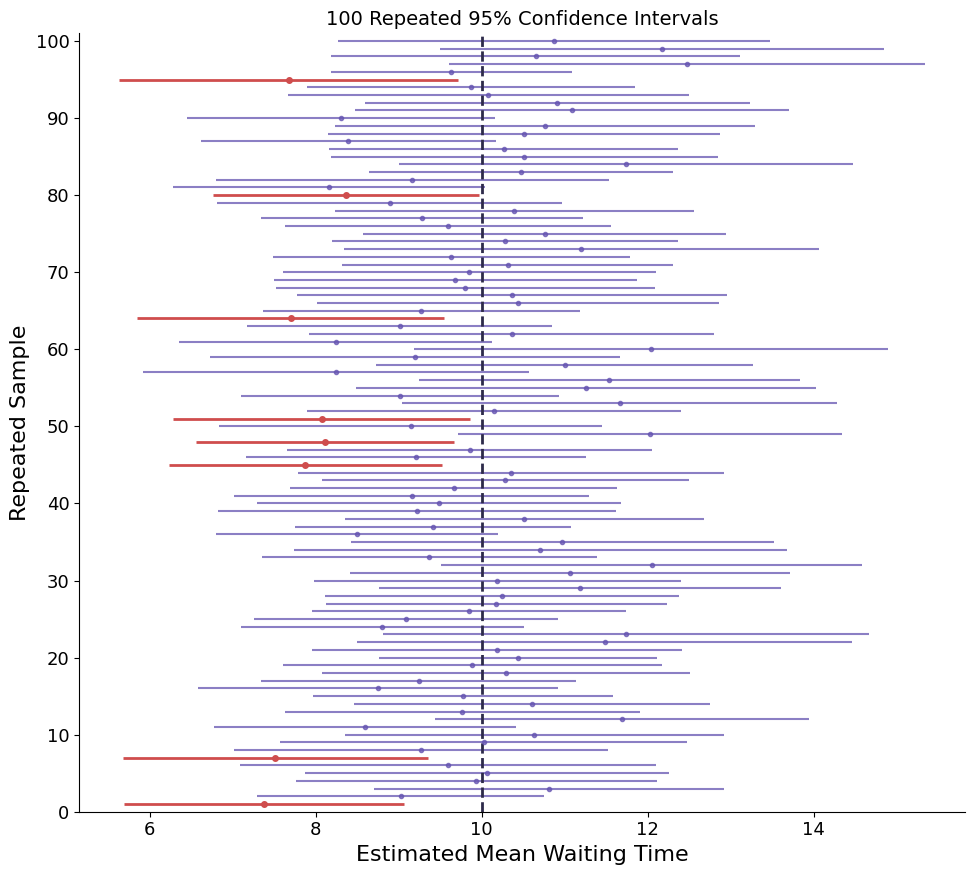

Coverage: 92 / 100 = 92.0%


In [75]:
n_rep = 100
n_ci = 80
true_mean = 10
alpha = 0.05

# Generate 100 samples of size 80
samples = rng.exponential(scale=true_mean, size=(n_rep, n_ci))

# Sample means and standard errors
means = samples.mean(axis=1)
ses = samples.std(axis=1, ddof=1) / np.sqrt(n_ci)

# 95% t critical value
t_crit = stats.t.ppf(1 - alpha / 2, df=n_ci - 1)

# Confidence intervals
margins = t_crit * ses
lower = means - margins
upper = means + margins

# Does each interval contain the true mean?
covers = (lower <= true_mean) & (true_mean <= upper)

# Plotting the confidence intervals
fig, ax = plt.subplots(figsize=(10, 9))
y = np.arange(1, n_rep + 1)

# Plot intervals that cover the true mean
ax.errorbar(means[covers], y[covers], xerr=margins[covers], fmt="o", markersize=3, capsize=0, color="#6554B1", alpha=0.75)

# Plot intervals that miss the true mean
ax.errorbar(means[~covers], y[~covers], xerr=margins[~covers], fmt="o", markersize=4, capsize=0, color="#CF4D4D", linewidth=2)

# True population mean
ax.axvline(true_mean, color="#2D2A4A", linestyle="--", linewidth=2, label=f"True mean = {true_mean}")
ax.set_title(f"100 Repeated 95% Confidence Intervals", fontsize=14)

ax.set_xlabel("Estimated Mean Waiting Time")
ax.set_ylabel("Repeated Sample")
ax.set_yticks(np.arange(0, n_rep + 1, 10))
ax.set_ylim(0, n_rep + 1)
plt.tight_layout()
plt.show()

coverage = covers.mean()
print(f"Coverage: {covers.sum()} / {n_rep} = {coverage:.1%}")

## 3. Back to Causal Inference

Let $S$ denote job training, $Y$ later earnings, and $U$ other causes of earnings. The estimand is

$$ATE=\mathbb E[Y(S=1,U)-Y(S=0,U)].$$

### Observational data versus Experiments

In **observational data**, treatment choice is generated by people, institutions, or circumstances. If workers who are struggling to find work are more likely to apply for training, then $S$ can depend on $U$. The observed difference

$$\mathbb E[Y\mid S=1]-\mathbb E[Y\mid S=0]$$

can mix the effect of training with selection bias. It is not automatically the ATE.

In an **experiment**, the researcher actively assigns treatment. A **randomized controlled trial (RCT)** uses a known random procedure to decide treatment assignment. This makes the assigned treatment groups comparable before outcomes are observed.

### Example 4: Association or Causal effect?

A training program compares volunteers who enrolled with people who did not. Is this observational data or an RCT? What unobserved characteristics could make the income difference misleading?

Now suppose the program randomly offers training to eligible applicants. What changes, and what still needs to be true before the difference in outcomes identifies the ATE?

### Assumptions and identification

To use the observed treatment-control difference as the ATE, we need the following assumptions.

***Randomization:*** assignment is generated without using $U$.

***Perfect compliance:*** treatment received equals assignment, $S=S_A$.

***SUTVA (Stable Unit Treatment Value Assumption):*** no interference between units and no hidden versions of treatment.

Randomization plus compliance give $S\perp U$; SUTVA makes potential outcomes well-defined. Together,

$$ATE=\mathbb E[Y\mid S=1]-\mathbb E[Y\mid S=0].$$

What can we check? Audit assignment and compare pre-treatment covariates for randomization; look for spillovers or treatment versions for SUTVA; follow up with participants for compliance. Balance tests can flag problems with randomization, but cannot prove it or test SUTVA.

### If assumptions fail

- Failed randomization: the simple difference is not automatically causal.
- SUTVA failure: redesign the intervention or analysis unit; do not interpret the simple comparison as the individual ATE.
- Imperfect compliance: compare outcomes by randomized assignment to estimate an intent-to-treat effect (ITT).

## 4. Simulated experiment

This is a deliberately transparent toy population. It shows why observational selection can bias a difference in means.

For each of 800 workers, the simulation creates:

- $U$: unobserved job readiness; higher values mean better employment prospects.
- `past_earnings`: an observed **pre-treatment** proxy for job readiness.
- $Y(0)$: potential earnings without training.
- $Y(1)$: potential earnings with training.
- $Y(1)-Y(0)$ (`effect`): that worker's individual treatment effect.

The simulation lets us see both potential outcomes and the true ATE. In a real study, we see only one outcome per worker.

In [10]:
n = 800

# U is job readiness. It affects past earnings and both potential outcomes,
# but would be unobserved in an actual data set.
u = rng.normal(size=n)
past = 9_000 + 3_000 * u + rng.normal(0, 2_000, n)
y0 = 10_000 + 4_000 * u + rng.normal(0, 4_500, n)  # Y(0): no training
effect = 1_500 + rng.normal(0, 500, n)             # Y(1) - Y(0)
y1 = y0 + effect                                    # Y(1): training
true_ate = effect.mean()

# Observational world: workers with lower U are more likely to volunteer.
# This makes treatment status associated with U and creates selection bias.
p_volunteer = 1 / (1 + np.exp(1.1 * u))
s_obs = rng.binomial(1, p_volunteer)
y_obs = np.where(s_obs == 1, y1, y0)  # only one potential outcome is observed

# Experimental world: assignment is a fair coin flip and everyone complies.
# Hence S is independent of U in this simulated RCT.
s = rng.binomial(1, 0.5, n)
y = np.where(s == 1, y1, y0)
experiment = pd.DataFrame({"S": s, "past_earnings": past, "earnings_after": y})

display(experiment.sample(5, random_state=2026))
print(f"True ATE in the simulated population: {true_ate:,.0f}")
print(f"Observational treatment-control difference: {y_obs[s_obs == 1].mean() - y_obs[s_obs == 0].mean():,.0f}")

,S,past_earnings,earnings_after
113,1,8535.811,10642.736
572,0,9864.336,20340.962
377,1,5068.434,5515.441
495,0,8088.555,6940.951
52,0,12016.153,17332.719


True ATE in the simulated population: 1,468
Observational treatment-control difference: -1,671


### Balance and causal effect

Which column belongs in the balance test?

In [70]:
treated = experiment.query("S == 1")
control = experiment.query("S == 0")
balance = stats.ttest_ind(treated.past_earnings, control.past_earnings, equal_var=False)
print(f"Treated mean past earnings = {treated.past_earnings.mean():,.0f}; Control mean past earnings = {control.past_earnings.mean():,.0f}")

print(f"test statistic = {balance.statistic:.3f}; df = {balance.df:.1f}; p-value = {balance.pvalue:.4g}")

Treated mean past earnings = 8,972; Control mean past earnings = 8,892
test statistic = 0.310; df = 798.0; p-value = 0.757


### Imperfect compliance and ITT

With noncompliance, $S_A$ remains randomized but actual receipt $S$ need not be. The ITT is

$$ITT=\mathbb E[Y(S_A=1,U)-Y(S_A=0,U)].$$

In [74]:
s_a = rng.binomial(1, .5, n)
p_receive = 1 / (1 + np.exp(-(-0.4 + 1.6 * s_a + .45 * u)))
s_received = rng.binomial(1, p_receive)
y_nc = np.where(s_received == 1, y1, y0)
itt = stats.ttest_ind(y_nc[s_a == 1], y_nc[s_a == 0], equal_var=False, alternative="greater")

print(f"Difference by receipt = {y_nc[s_received == 1].mean() - y_nc[s_received == 0].mean():,.0f}")
print(f"Difference by assignment = {y_nc[s_a == 1].mean() - y_nc[s_a == 0].mean():,.0f}")
print(f"test statistic = {itt.statistic:.3f}; df = {itt.df:.1f}; p-value = {itt.pvalue:.4g}")

Difference by receipt = 2,578
Difference by assignment = 255
test statistic = 0.575; df = 797.6; p-value = 0.2828
